# Grouping

Grouping methods aim to divide data into meaningful subsets, typically to identify patterns, behaviors, or structures in data. These approaches are widely used in data mining, marketing analytics, and machine learning.

## Clustering
Clustering groups observations so that elements within the same group are more similar to each other than to those in other groups. It is an unsupervised learning technique, meaning no predefined labels are required.

### Hierarchical Methods
Hierarchical clustering builds a tree-like structure (dendrogram) representing nested groupings of observations.
- Agglomerative (bottom-up): each observation starts as its own cluster and clusters are merged.
- Divisive (top-down): all observations start in one cluster and are recursively split.
- Does not require pre-specifying the number of clusters.
- Sensitive to distance metrics and linkage criteria (single, complete, average).

### Partition Methods
Partition-based methods divide the data into a fixed number of clusters by optimizing a criterion, usually within-cluster similarity.
- **K-means**: clusters are represented by centroids (means).
- **K-medoids**: clusters are represented by actual observations (medoids), making it more robust to outliers.
- Requires specifying the number of clusters in advance.
- Works best with spherical, well-separated clusters.

### DBSCAN (HDBSCAN)
Density-based clustering methods identify clusters as areas of high point density.
- **DBSCAN**: groups points that are closely packed and labels sparse regions as noise.
- Does not require specifying the number of clusters.
- Can detect arbitrarily shaped clusters.
- **HDBSCAN**: hierarchical extension that handles variable density clusters better.

### Shift Mean (Mean Shift)
Mean Shift is a mode-seeking algorithm that moves data points toward regions of higher density.
- Does not require predefining the number of clusters.
- Clusters are defined by density peaks.
- Computationally expensive for large datasets.
- Sensitive to bandwidth selection.

### Self-Organizing Maps
Self-Organizing Maps (SOMs) are neural-network-based clustering and visualization techniques.
- Map high-dimensional data into a lower-dimensional (usually 2D) grid.
- Preserve topological relationships.
- Useful for visualization and exploratory analysis.
- Require training and parameter tuning.

## Cohort Analysis
Cohort analysis groups individuals based on shared characteristics or events over time.
- Commonly used in customer analytics and retention analysis.
- Cohorts are often defined by acquisition date or first interaction.
- Allows comparison of behavior across different cohorts.
- Emphasizes temporal dynamics rather than static similarity.

## Cell-based Segments
Cell-based segmentation creates predefined segments by crossing multiple variables into discrete categories.
- Segments are rule-based rather than data-driven.
- Easy to interpret and communicate.
- Widely used in marketing and business analytics.

### Variables
Segmentation is based on categorical or discretized variables.
- Examples: age groups, income levels, geographic regions.
- Each combination of variable categories defines a segment (cell).
- Number of segments grows exponentially with the number of variables.

### Through time
Cell-based segments can be tracked across time.
- Enables analysis of transitions between segments.
- Useful for monitoring behavioral changes.
- Supports longitudinal analysis and trend detection.

### RFM Analysis
RFM segmentation is a classic cell-based approach in marketing.
- **Recency**: how recently a customer made a purchase.
- **Frequency**: how often a customer purchases.
- **Monetary value**: how much a customer spends.
- Customers are scored and grouped based on these dimensions.
- Simple, interpretable, and widely used in CRM.


In [36]:
!pip install hdbscan minisom umap-learn

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN, MeanShift, estimate_bandwidth
from sklearn.metrics import silhouette_score
from sklearn.manifold import TSNE
from scipy.cluster.hierarchy import dendrogram, linkage

import hdbscan
from minisom import MiniSom
import umap

import warnings
warnings.filterwarnings('ignore')

In [38]:
X_scaled = pd.read_csv('X_scaled.csv', index_col='customer_id')

In [39]:
pca = PCA(n_components=13, random_state=42)
X_pca = pca.fit_transform(X_scaled)
X_pca = pd.DataFrame(X_pca, index=X_scaled.index)

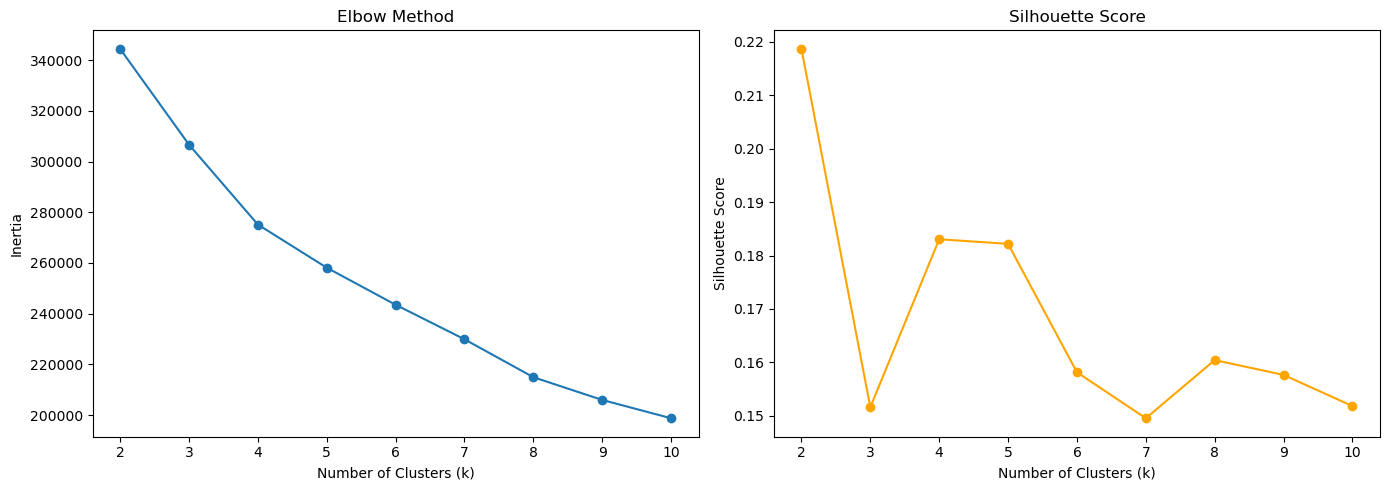

In [40]:
inertias = []
silhouettes = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_pca)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_pca, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(k_range, inertias, marker='o')
axes[0].set_title('Elbow Method')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')

axes[1].plot(k_range, silhouettes, marker='o', color='orange')
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')

plt.tight_layout()
plt.show()

K = 4

# Partition Methods

In [41]:
# ── K-Means ────────────────────────────────────────────────────────────────
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_pca)
kmeans_score = silhouette_score(X_pca, kmeans_labels)
print(f"K-Means        silhouette={kmeans_score:.3f}  clusters={len(set(kmeans_labels))}")

K-Means        silhouette=0.183  clusters=4


In [42]:
# ── K-Medoids ──────────────────────────────────────────────────────────────
#kmedoids = KMedoids(n_clusters=4, random_state=42)
#kmedoids_labels = kmedoids.fit_predict(X_pca)
#kmedoids_score = silhouette_score(X_pca, kmedoids_labels)
#print(f"K-Medoids      silhouette={kmedoids_score:.3f}  clusters={len(set(kmedoids_labels))}")

# Hierchical Clustering

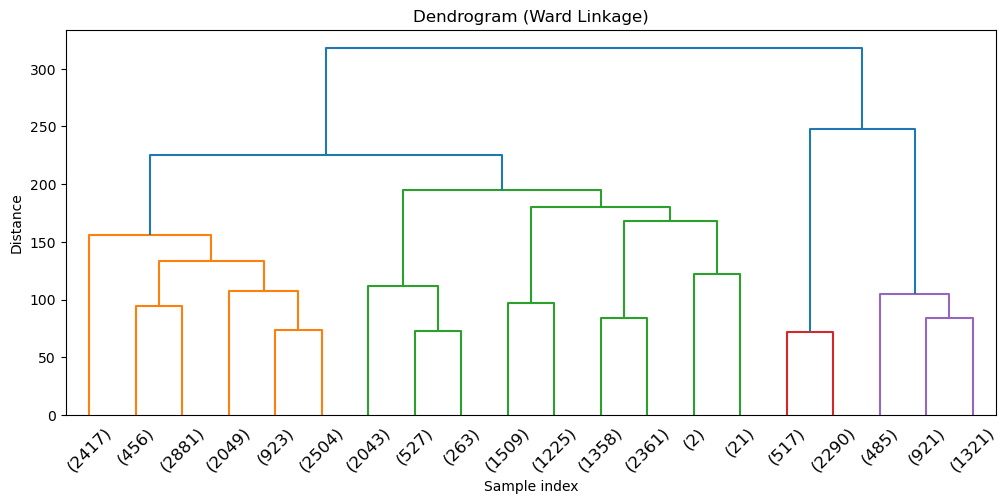

Agglomerative (ward      )  silhouette=0.140
Agglomerative (complete  )  silhouette=0.660
Agglomerative (average   )  silhouette=0.866
Agglomerative (single    )  silhouette=0.866


In [43]:
# ── Dendrogram to visualize structure ──────────────────────────────────────
linked = linkage(X_pca, method='ward')

plt.figure(figsize=(12, 5))
dendrogram(linked, truncate_mode='lastp', p=20, leaf_rotation=45)
plt.title('Dendrogram (Ward Linkage)')
plt.xlabel('Sample index')
plt.ylabel('Distance')
plt.show()

# ── Agglomerative with different linkages ──────────────────────────────────
linkages = ['ward', 'complete', 'average', 'single']

for linkage_method in linkages:
    agg = AgglomerativeClustering(n_clusters=4, linkage=linkage_method)
    agg_labels = agg.fit_predict(X_pca)
    score = silhouette_score(X_pca, agg_labels)
    print(f"Agglomerative ({linkage_method:<10})  silhouette={score:.3f}")

# DBSCAN

In [44]:
# ── DBSCAN ─────────────────────────────────────────────────────────────────
dbscan = DBSCAN(eps=0.5, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_pca)
n_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = (dbscan_labels == -1).sum()
if n_clusters >= 2:
    score = silhouette_score(X_pca, dbscan_labels)
    print(f"DBSCAN         silhouette={score:.3f}  clusters={n_clusters}  noise={n_noise}")
else:
    print(f"DBSCAN         clusters={n_clusters}  noise={n_noise}  (tune eps/min_samples)")

DBSCAN         clusters=0  noise=26073  (tune eps/min_samples)


In [45]:
# ── HDBSCAN ────────────────────────────────────────────────────────────────
hdb = hdbscan.HDBSCAN(min_cluster_size=50, min_samples=5)
hdb_labels = hdb.fit_predict(X_pca)
n_clusters = len(set(hdb_labels)) - (1 if -1 in hdb_labels else 0)
n_noise = (hdb_labels == -1).sum()
if n_clusters >= 2:
    score = silhouette_score(X_pca, hdb_labels)
    print(f"HDBSCAN        silhouette={score:.3f}  clusters={n_clusters}  noise={n_noise}")
else:
    print(f"HDBSCAN        clusters={n_clusters}  noise={n_noise}  (tune min_cluster_size)")

HDBSCAN        silhouette=0.077  clusters=2  noise=2874


# Mean Shift

In [46]:
ms = MeanShift()
ms_labels = ms.fit_predict(X_pca)
n_clusters = len(set(ms_labels))
score = silhouette_score(X_pca, ms_labels)
print(f"Mean Shift     silhouette={score:.3f}  clusters={n_clusters}")

Mean Shift     silhouette=0.484  clusters=13


# Self organizing map

 [ 10000 / 10000 ] 100% - 0:00:00 left 
 quantization error: 2.1012897171795193
SOM + KMeans   silhouette=0.170  clusters=4


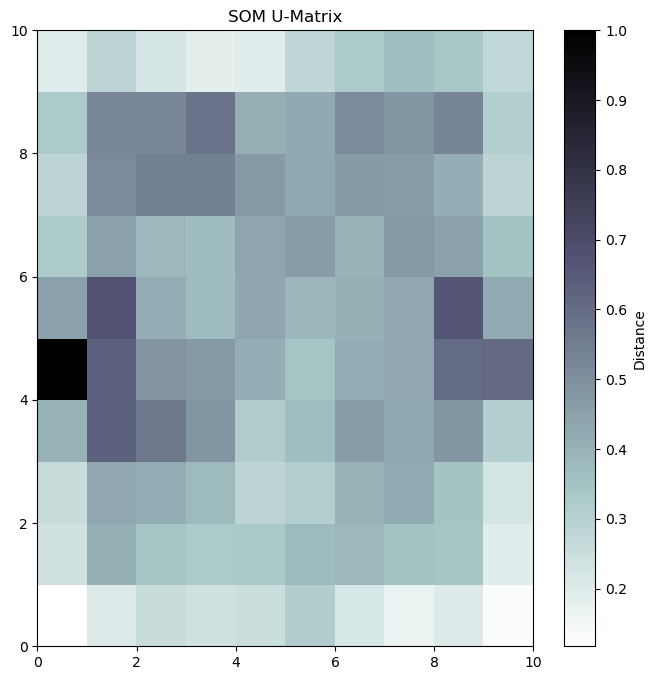

In [47]:
# ── Train SOM ──────────────────────────────────────────────────────────────
som_x, som_y = 10, 10
som = MiniSom(
    x=som_x, y=som_y,
    input_len=X_pca.shape[1],
    sigma=1.0,
    learning_rate=0.5,
    random_seed=42
)

X_pca_array = X_pca.values  # convert to numpy

som.random_weights_init(X_pca_array)
som.train(X_pca_array, num_iteration=10000, verbose=True)

# ── Assign each customer to a neuron ───────────────────────────────────────
winner_coordinates = np.array([som.winner(x) for x in X_pca_array])

# ── Map neurons to k=4 clusters using K-Means on neuron weights ────────────
weights = som.get_weights().reshape(-1, X_pca_array.shape[1])
kmeans_som = KMeans(n_clusters=4, random_state=42, n_init=10)
neuron_labels = kmeans_som.fit_predict(weights)

som_labels = np.array([
    neuron_labels[x * som_y + y] for x, y in winner_coordinates
])

score = silhouette_score(X_pca_array, som_labels)
print(f"SOM + KMeans   silhouette={score:.3f}  clusters={len(set(som_labels))}")

# ── U-Matrix visualization ─────────────────────────────────────────────────
plt.figure(figsize=(8, 8))
plt.pcolor(som.distance_map().T, cmap='bone_r')
plt.colorbar(label='Distance')
plt.title('SOM U-Matrix')
plt.show()


# Visualization

In [48]:
X_tsne = TSNE(n_components=2, perplexity=30, random_state=42).fit_transform(X_pca)
X_umap = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=42).fit_transform(X_pca)

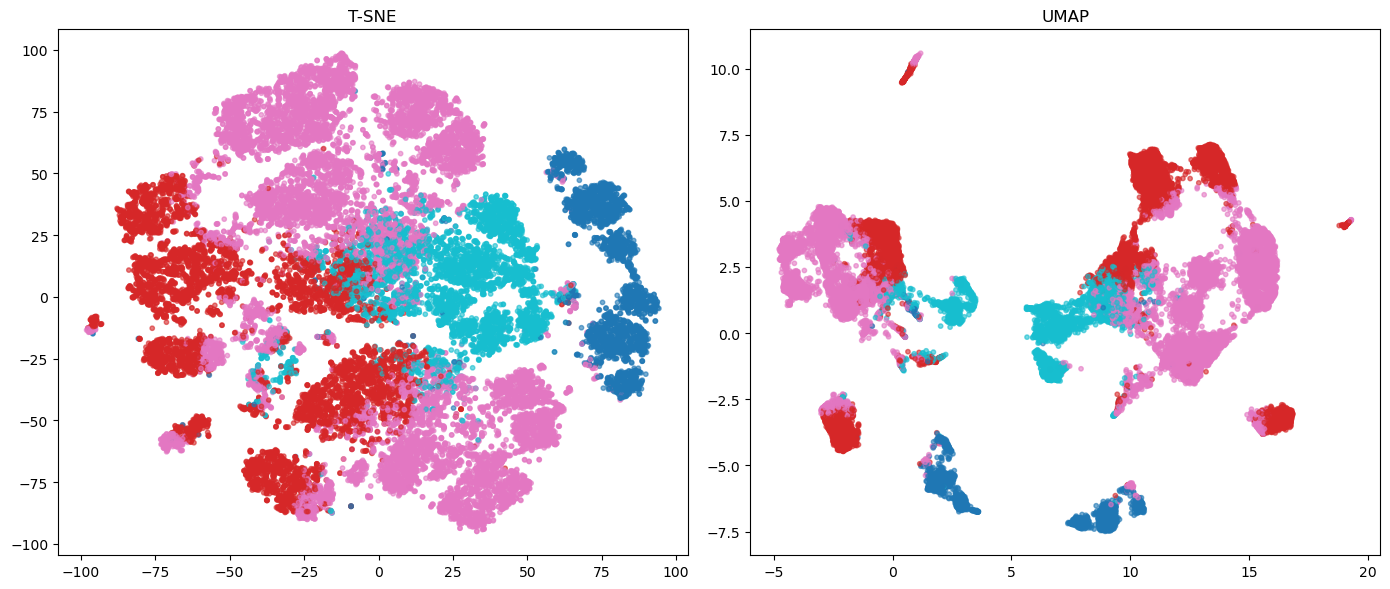

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(X_tsne[:, 0], X_tsne[:, 1], c=kmeans_labels, cmap='tab10', alpha=0.6, s=10)
axes[0].set_title('T-SNE')

axes[1].scatter(X_umap[:, 0], X_umap[:, 1], c=kmeans_labels, cmap='tab10', alpha=0.6, s=10)
axes[1].set_title('UMAP')

plt.tight_layout()
plt.show()

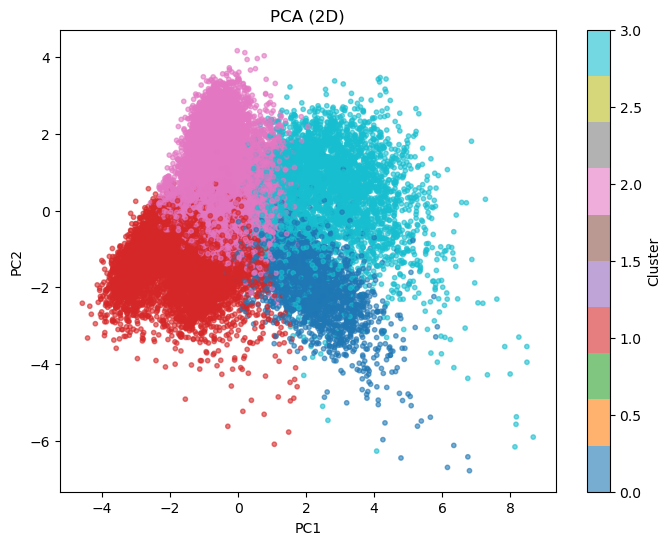

In [50]:
# 2D PCA just for visualization
pca_2d = PCA(n_components=2, random_state=42)
X_pca_2d = pca_2d.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=kmeans_labels, cmap='tab10', alpha=0.6, s=10)
plt.title('PCA (2D)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.colorbar(label='Cluster')
plt.show()